# Fertilizer Recommendation System using Machine Learning

This module predicts the most suitable fertilizer for a crop based on soil nutrients,
environmental conditions, soil type, and crop type.

Dataset Features:
- Temperature
- Humidity
- Moisture
- Soil Type
- Crop Type
- Nitrogen
- Potassium
- Phosphorous
- Fertilizer Name (Target Variable)

In [2]:
# Importing Libraries 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# Load dataset
fert_df = pd.read_csv("Fertilizer Prediction.csv")

# Check dataset shape
print("Dataset Shape:", fert_df.shape)

# Display first few rows
fert_df.head()

Dataset Shape: (99, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [5]:
# Fix spelling of Temparature → Temperature
fert_df.rename(columns={"Temparature": "Temperature"}, inplace=True)

# Display column names
print("Columns in dataset:")
print(fert_df.columns)
# Remove extra spaces from column names
fert_df.columns = fert_df.columns.str.strip()

# Show cleaned column names
print("Cleaned Columns:")
print(fert_df.columns)

Columns in dataset:
Index(['Temperature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')
Cleaned Columns:
Index(['Temperature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


In [6]:
# Dataset information
print("Dataset Info:\n")
fert_df.info()

# Check missing values
print("\nMissing Values:\n")
print(fert_df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", fert_df.duplicated().sum())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temperature      99 non-null     int64 
 1   Humidity         99 non-null     int64 
 2   Moisture         99 non-null     int64 
 3   Soil Type        99 non-null     object
 4   Crop Type        99 non-null     object
 5   Nitrogen         99 non-null     int64 
 6   Potassium        99 non-null     int64 
 7   Phosphorous      99 non-null     int64 
 8   Fertilizer Name  99 non-null     object
dtypes: int64(6), object(3)
memory usage: 7.1+ KB

Missing Values:

Temperature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

Duplicate Rows: 0


In [7]:
# Statistical summary of numerical columns
fert_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,99.0,30.282828,3.502304,25.0,28.0,30.0,33.0,38.0
Humidity,99.0,59.151515,5.840331,50.0,54.0,60.0,64.0,72.0
Moisture,99.0,43.181818,11.271568,25.0,34.0,41.0,50.5,65.0
Nitrogen,99.0,18.909091,11.599693,4.0,10.0,13.0,24.0,42.0
Potassium,99.0,3.383838,5.814667,0.0,0.0,0.0,7.5,19.0
Phosphorous,99.0,18.606061,13.476978,0.0,9.0,19.0,30.0,42.0


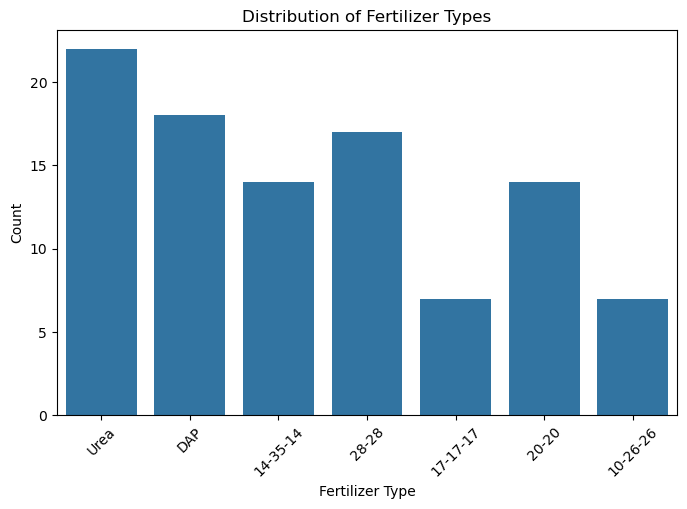

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fert_df,
    x="Fertilizer Name"
)

plt.title("Distribution of Fertilizer Types")
plt.xlabel("Fertilizer Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [9]:
# Initialize encoders
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()

# Encode categorical columns
fert_df["Soil Type"] = le_soil.fit_transform(fert_df["Soil Type"])
fert_df["Crop Type"] = le_crop.fit_transform(fert_df["Crop Type"])
fert_df["Fertilizer Name"] = le_fert.fit_transform(fert_df["Fertilizer Name"])

# Show updated dataset
fert_df.head()

,Temperature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,4,3,37,0,0,6
1,29,52,45,2,8,12,0,36,5
2,34,65,62,0,1,7,9,30,1
3,32,62,34,3,9,22,0,20,4
4,28,54,46,1,6,35,0,0,6


In [10]:
# Features (input variables)
X_fert = fert_df.drop("Fertilizer Name", axis=1)

# Target variable
y_fert = fert_df["Fertilizer Name"]

print("Feature Shape:", X_fert.shape)
print("Target Shape:", y_fert.shape)

X_fert.head()

Feature Shape: (99, 8)
Target Shape: (99,)


,Temperature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous
0,26,52,38,4,3,37,0,0
1,29,52,45,2,8,12,0,36
2,34,65,62,0,1,7,9,30
3,32,62,34,3,9,22,0,20
4,28,54,46,1,6,35,0,0


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Random Forest model
fert_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross validation scores
cv_scores = cross_val_score(
    fert_model,
    X_fert,
    y_fert,
    cv=skf,
    scoring='accuracy'
)

print("Cross Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross Validation Accuracy Scores: [1.   1.   1.   0.95 1.  ]
Mean Accuracy: 0.99


A Stratified 5-Fold Cross Validation approach was used to evaluate the fertilizer recommendation model. The Random Forest classifier achieved an average accuracy of 99%, indicating strong predictive performance across different validation folds.

In [19]:
fert_model.fit(X_fert, y_fert)

print("Final model trained on full dataset")

Final model trained on full dataset


In [20]:
# Function to recommend fertilizer

def recommend_fertilizer(temperature, humidity, moisture, soil_type, crop_type,
                         nitrogen, potassium, phosphorous):

    # Encode soil and crop using the encoders we trained earlier
    soil_encoded = le_soil.transform([soil_type])[0]
    crop_encoded = le_crop.transform([crop_type])[0]

    # Create input array
    input_data = np.array([[temperature, humidity, moisture,
                            soil_encoded, crop_encoded,
                            nitrogen, potassium, phosphorous]])

    # Predict fertilizer
    prediction = fert_model.predict(input_data)

    # Convert encoded label back to fertilizer name
    fertilizer_name = le_fert.inverse_transform(prediction)

    return fertilizer_name[0]

In [22]:
recommend_fertilizer(
    temperature=30,
    humidity=60,
    moisture=42,
    soil_type="Sandy",
    crop_type="Millets",
    nitrogen=21,
    potassium=0,
    phosphorous=18
)

'28-28'

In [23]:
import joblib
# Save the trained fertilizer model
joblib.dump(fert_model, "fertilizer_model.pkl")

# Save encoders
joblib.dump(le_soil, "soil_encoder.pkl")
joblib.dump(le_crop, "crop_encoder.pkl")
joblib.dump(le_fert, "fertilizer_encoder.pkl")

print("Model and encoders saved successfully!")

Model and encoders saved successfully!
